# MCQ Evaluation: KG-Augmented Chatbot vs Vanilla LLMs

**Setup:** 250 multiple-choice questions (100 one-hop, 100 two-hop, 50 general) over the AlloyGraph knowledge graph.

| System | Description |
|--------|-------------|
| **Chatbot + KG** | RAG chatbot backed by Weaviate KG (Llama 3.3 70B) |
| **Llama 3.3 70B** | Vanilla LLM, no retrieval |
| **GPT-4o** | Vanilla LLM, no retrieval |

**Question types**
- *One-hop* — single KG lookup (property at temp, TCP risk, processing, composition, gamma prime, density)
- *Two-hop* — multi-step reasoning (filter + rank, dual threshold, pairwise comparison, temp retention, filtered ranking)
- *General* — conceptual metallurgy questions requiring domain reasoning (mechanism links, thresholds, property intersections)

In [1]:
import json, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130})

ROOT = Path("..")
OUT  = ROOT / "results"

In [2]:
# ── Load data ────────────────────────────────────────────────────────────
with open(OUT / "mcq_report.json") as f:
    report = json.load(f)

SYSTEMS = {"chatbot": "Chatbot + KG", "llama": "Llama 3.3 70B", "gpt": "GPT-4o"}
SYS_ORDER = list(SYSTEMS.values())

SUBTYPE_LABELS = {
    "property_at_temp": "Property @ Temp", "tcp_risk": "TCP Risk",
    "processing_method": "Processing", "composition_element": "Composition",
    "gamma_prime": "Gamma Prime", "density": "Density",
    "comp_filter_rank": "Filter + Rank", "dual_threshold": "Dual Threshold",
    "pairwise_comparison": "Pairwise Comp.", "temp_retention": "Temp Retention",
    "filtered_ranking": "Filtered Rank",
    # General subtypes
    "multi_hop_ranking": "Multi-Hop Rank", "mechanism_threshold": "Mechanism Threshold",
    "mechanism_comparison": "Mechanism Comp.", "property_intersection": "Property Intersection",
    "mechanism_property_link": "Mechanism-Property", "threshold_comparison": "Threshold Comp.",
    "retention_comparison": "Retention Comp.",
}

# Long-format: one row per (question, system)
rows = []
for key, label in SYSTEMS.items():
    for hop in ["1hop", "2hop", "general"]:
        if hop not in report["systems"][key]:
            continue
        for q in report["systems"][key][hop]["per_question"]:
            rows.append(dict(
                id=q["id"], hop=hop, subtype=q["subtype"],
                system=label, extracted=q.get("extracted"),
                correct_answer=q["correct_answer"],
                is_correct=q.get("is_correct", False),
            ))
df = pd.DataFrame(rows)
df["subtype_label"] = df["subtype"].map(SUBTYPE_LABELS).fillna(df["subtype"])

# Wide-format: one row per question, bool columns per system
wide = (df.pivot_table(index=["id", "hop", "subtype", "correct_answer"],
                       columns="system", values="is_correct", aggfunc="first")
          .reset_index())
ans_wide = df.pivot_table(index="id", columns="system", values="extracted", aggfunc="first")
ans_wide.columns = [f"{c}_ans" for c in ans_wide.columns]
wide = wide.merge(ans_wide, on="id")

n1 = (wide.hop == "1hop").sum()
n2 = (wide.hop == "2hop").sum()
ng = (wide.hop == "general").sum()
print(f"Loaded {len(wide)} questions  ({n1} one-hop, {n2} two-hop, {ng} general)")

Loaded 250 questions  (100 one-hop, 100 two-hop, 50 general)


---
## 1 &ensp; Overall Accuracy

In [3]:
acc = (df.groupby(["system", "hop"])["is_correct"]
         .mean().unstack()
         .rename(columns={"1hop": "1-Hop", "2hop": "2-Hop"}))
acc["Overall"] = df.groupby("system")["is_correct"].mean()
acc = acc.loc[SYS_ORDER]

(acc.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", vmin=0.2, vmax=1.0)
    .set_caption("Table 1 — Accuracy by system and question type"))

hop,1-Hop,2-Hop,general,Overall
system,,,,
Chatbot + KG,100.0%,79.0%,98.0%,91.2%
Llama 3.3 70B,35.0%,43.0%,92.0%,49.6%
GPT-4o,33.0%,42.0%,100.0%,50.0%


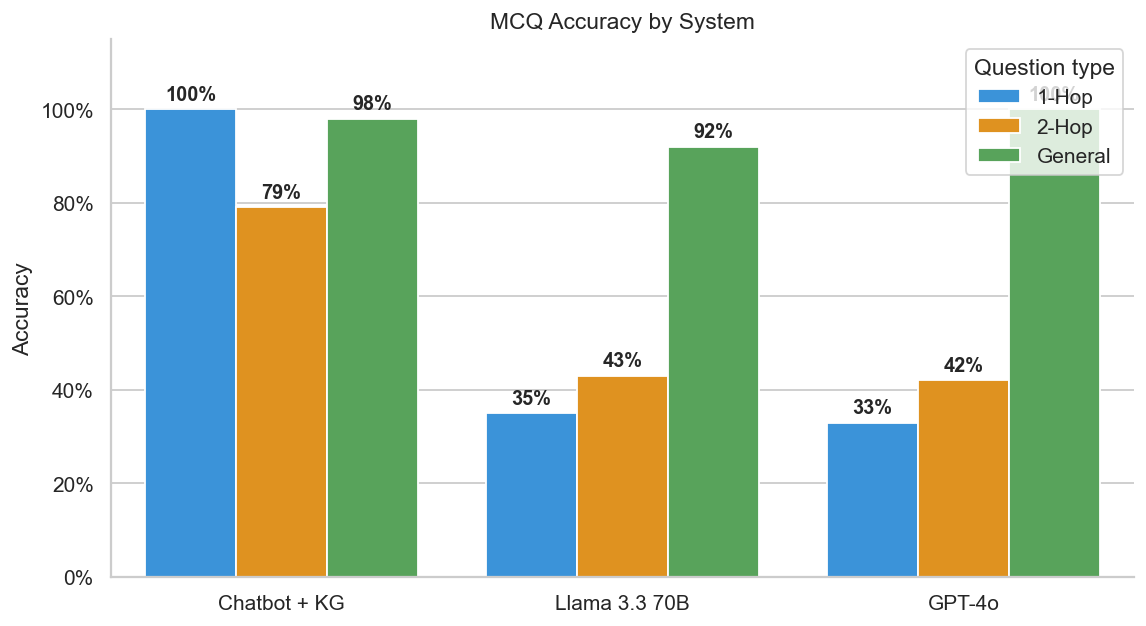

In [4]:
plot_df = (df.groupby(["system", "hop"])["is_correct"].mean()
             .reset_index()
             .replace({"1hop": "1-Hop", "2hop": "2-Hop", "general": "General"}))
plot_df["system"] = pd.Categorical(plot_df["system"], SYS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = sns.barplot(data=plot_df, x="system", y="is_correct", hue="hop",
                   palette=["#2196F3", "#FF9800", "#4CAF50"], ax=ax)
for c in bars.containers:
    bars.bar_label(c, fmt=lambda v: f"{v * 100:.0f}%",
                   label_type="edge", padding=3, fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set(xlabel="", ylabel="Accuracy", title="MCQ Accuracy by System")
ax.legend(title="Question type")
sns.despine()
plt.tight_layout()
plt.savefig(OUT / "mcq_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Publication Figure — MCQ Accuracy

Saved: ../figures/fig_mcq_accuracy.png and .pdf


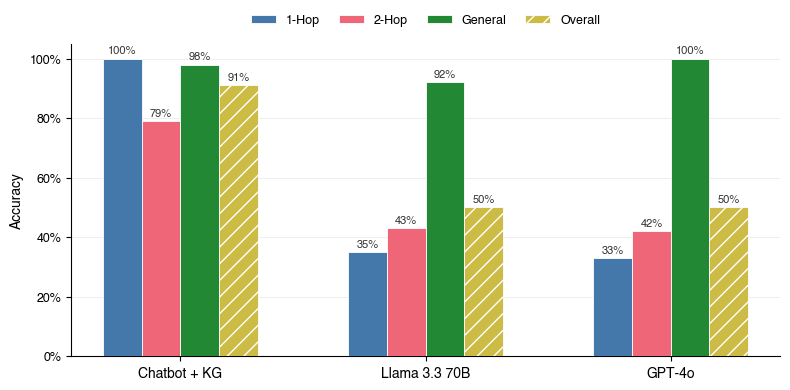

In [5]:
import os, numpy as np, matplotlib.pyplot as plt
import matplotlib
matplotlib.rcdefaults()
os.makedirs("../figures", exist_ok=True)

# Data
systems = ["Chatbot + KG", "Llama 3.3 70B", "GPT-4o"]
categories = ["1-Hop", "2-Hop", "General", "Overall"]
data = {
    "1-Hop":   [100, 35, 33],
    "2-Hop":   [79, 43, 42],
    "General": [98, 92, 100],
    "Overall": [91, 50, 50],
}

# Tol muted palette
colors = {"1-Hop": "#4477AA", "2-Hop": "#EE6677", "General": "#228833", "Overall": "#CCBB44"}
hatches = {"1-Hop": "", "2-Hop": "", "General": "", "Overall": "//"}

# Font
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, ax = plt.subplots(figsize=(8, 4))

n_systems = len(systems)
n_cats = len(categories)
bar_width = 0.17
group_width = n_cats * bar_width
group_gap = 0.4
group_positions = np.arange(n_systems) * (group_width + group_gap)

for i, cat in enumerate(categories):
    x = group_positions + i * bar_width
    bars = ax.bar(x, data[cat], bar_width,
                  label=cat, color=colors[cat], hatch=hatches[cat],
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, val in zip(bars, data[cat]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.0,
                f"{val}%", ha="center", va="bottom", fontsize=8, color="#333333")

# Axes
ax.set_ylim(0, 105)
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([f"{y}%" for y in range(0, 101, 20)], fontsize=9)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_xticks(group_positions + group_width / 2 - bar_width / 2)
ax.set_xticklabels(systems, fontsize=10)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Slim horizontal gridlines
for y in range(20, 101, 20):
    ax.axhline(y=y, color="#E8E8E8", linewidth=0.5, zorder=1)

# Legend — horizontal, top center
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.13),
          ncol=4, frameon=False, fontsize=9, columnspacing=1.5)

plt.tight_layout()
fig.savefig("../figures/fig_mcq_accuracy.png", dpi=300, bbox_inches="tight")
fig.savefig("../figures/fig_mcq_accuracy.pdf", bbox_inches="tight")
print("Saved: ../figures/fig_mcq_accuracy.png and .pdf")
plt.show()


---
## 2 &ensp; Accuracy by Question Subtype

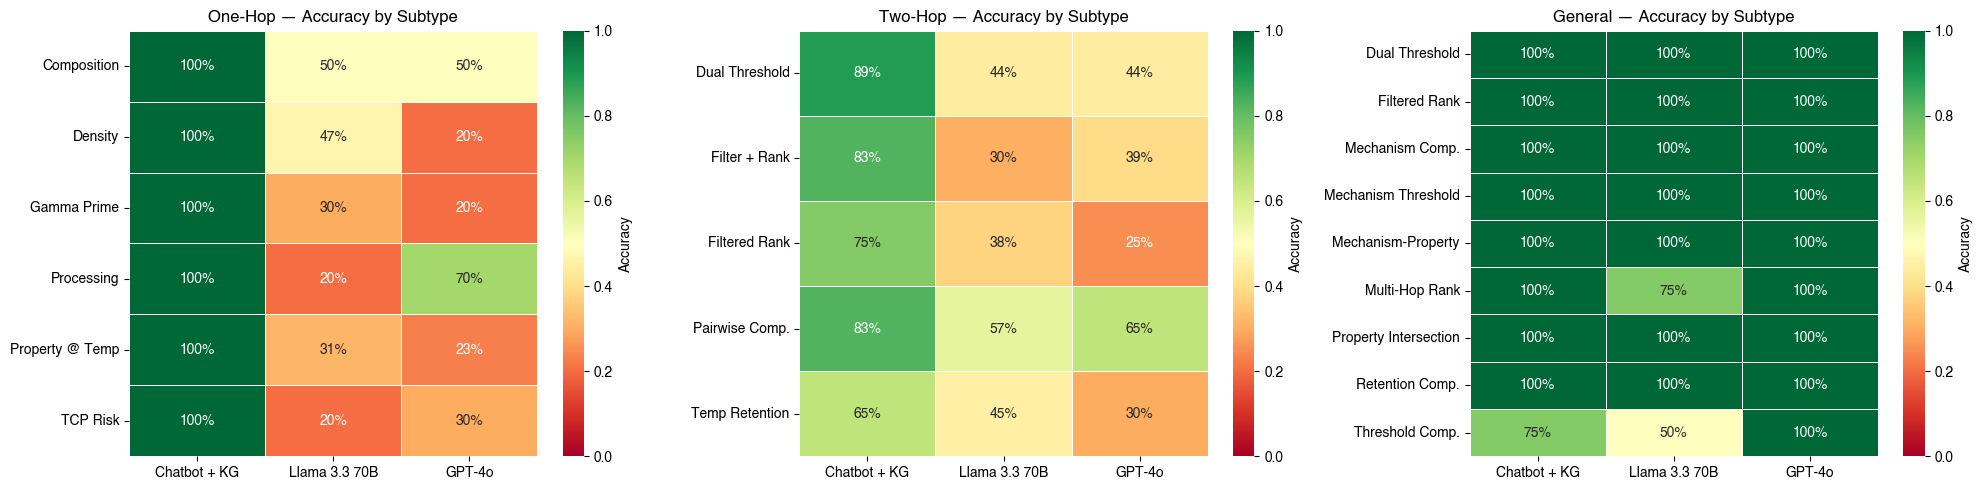

In [6]:
hop_panels = [("1hop", "One-Hop"), ("2hop", "Two-Hop"), ("general", "General")]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (hop, title) in enumerate(hop_panels):
    sub = df[df.hop == hop]
    if sub.empty:
        axes[idx].set_title(f"{title} — No data")
        continue
    mat = (sub.groupby(["subtype_label", "system"])["is_correct"].mean()
           .unstack()[SYS_ORDER])
    sns.heatmap(mat, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=.5, ax=axes[idx],
                cbar_kws={"label": "Accuracy"})
    axes[idx].set(title=f"{title} — Accuracy by Subtype", ylabel="", xlabel="")

plt.tight_layout()
plt.savefig(OUT / "mcq_subtype_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 &ensp; KG Context-Impact Analysis

Each question is classified by whether KG retrieval helped or hurt, relative to the best vanilla-LLM answer.

| Category | Definition |
|----------|------------|
| **KG helped** | Chatbot correct, at least one vanilla LLM wrong |
| **Both correct** | All three systems correct |
| **KG misled** | Chatbot wrong, at least one vanilla LLM correct |
| **All incorrect** | All three systems wrong |

In [7]:
def classify_impact(row):
    cb  = row["Chatbot + KG"]
    v_any = row["Llama 3.3 70B"] or row["GPT-4o"]
    v_all = row["Llama 3.3 70B"] and row["GPT-4o"]
    if cb and v_all:       return "Both correct"
    if cb and not v_all:   return "KG helped"
    if not cb and v_any:   return "KG misled"
    return "All incorrect"

wide["impact"] = wide.apply(classify_impact, axis=1)
CAT_ORDER = ["KG helped", "Both correct", "KG misled", "All incorrect"]

# Pivot table
tbl = (wide.groupby(["hop", "impact"]).size().unstack(fill_value=0)
           .reindex(columns=CAT_ORDER, fill_value=0)
           .rename(index={"1hop": "1-Hop", "2hop": "2-Hop", "general": "General"}))
tbl["Total"] = tbl.sum(axis=1)

display(tbl.style.set_caption("Table 2 — KG context impact (question counts)"))

impact,KG helped,Both correct,KG misled,All incorrect,Total
hop,,,,,
1-Hop,86,14,0,0,100
2-Hop,53,26,8,13,100
General,3,46,1,0,50


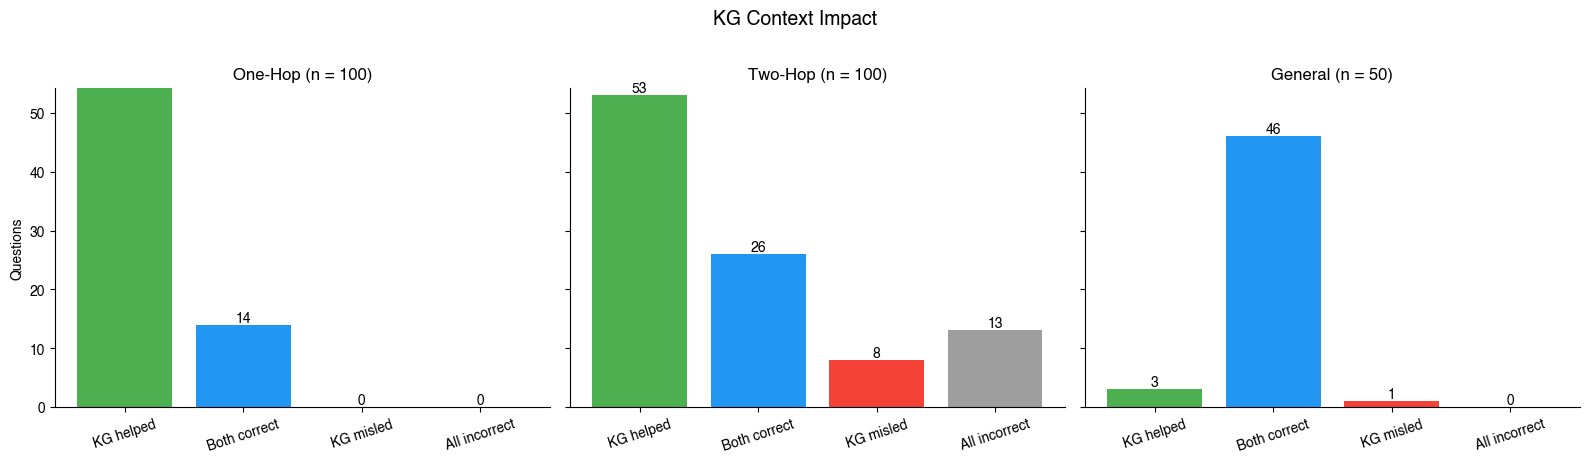

One-Hop:  +86 helped, -0 misled  =>  net +86
Two-Hop:  +53 helped, -8 misled  =>  net +45
General:  +3 helped, -1 misled  =>  net +2


In [8]:
COLORS = {"KG helped": "#4CAF50", "Both correct": "#2196F3",
          "KG misled": "#F44336", "All incorrect": "#9E9E9E"}

hop_panels = [("1hop", f"One-Hop (n = {n1})"),
              ("2hop", f"Two-Hop (n = {n2})"),
              ("general", f"General (n = {ng})")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for idx, (hop, title) in enumerate(hop_panels):
    sub = wide[wide.hop == hop]
    if sub.empty:
        axes[idx].set_title(title)
        continue
    counts = (sub["impact"].value_counts().reindex(CAT_ORDER, fill_value=0))
    bars = axes[idx].bar(counts.index, counts.values,
                         color=[COLORS[c] for c in counts.index])
    axes[idx].bar_label(bars, fontweight="bold")
    axes[idx].set(title=title,
                  ylabel="Questions" if idx == 0 else "",
                  ylim=(0, counts.max() * 1.18))
    axes[idx].tick_params(axis="x", rotation=18)

fig.suptitle("KG Context Impact", fontsize=14, fontweight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(OUT / "mcq_context_impact.png", dpi=150, bbox_inches="tight")
plt.show()

# Net impact
for hop, label in [("1hop", "One-Hop"), ("2hop", "Two-Hop"), ("general", "General")]:
    sub = wide[wide.hop == hop]
    if sub.empty:
        continue
    pos = (sub.impact == "KG helped").sum()
    neg = (sub.impact == "KG misled").sum()
    print(f"{label}:  +{pos} helped, -{neg} misled  =>  net +{pos - neg}")

---
## 4 &ensp; Error Analysis

Questions where **at least one system answered incorrectly**.  
`+` = correct, `x` = incorrect.

In [9]:
def error_table(hop_val):
    sub = wide[wide.hop == hop_val].copy()
    mask = ~(sub["Chatbot + KG"] & sub["Llama 3.3 70B"] & sub["GPT-4o"])
    err = sub[mask].copy()

    for short, full in [("Chatbot", "Chatbot + KG"),
                        ("Llama",   "Llama 3.3 70B"),
                        ("GPT",     "GPT-4o")]:
        err[short] = err.apply(
            lambda r: (str(r[f"{full}_ans"]) if pd.notna(r[f"{full}_ans"]) else "--")
                      + (" +" if r[full] else " x"), axis=1)

    return (err[["id", "subtype", "correct_answer",
                 "Chatbot", "Llama", "GPT", "impact"]]
            .rename(columns={"correct_answer": "Truth", "impact": "Category"})
            .reset_index(drop=True))

In [10]:
err1 = error_table("1hop")
err1.style.set_caption(f"One-Hop errors ({len(err1)} / {n1} questions)")

,id,subtype,Truth,Chatbot,Llama,GPT,Category
0,mcq_1hop_comp_001,composition_element,D,D +,C x,D +,KG helped
1,mcq_1hop_comp_002,composition_element,D,D +,C x,D +,KG helped
2,mcq_1hop_comp_003,composition_element,C,C +,C +,D x,KG helped
3,mcq_1hop_comp_004,composition_element,C,C +,C +,D x,KG helped
4,mcq_1hop_comp_005,composition_element,D,D +,C x,C x,KG helped
5,mcq_1hop_comp_007,composition_element,A,A +,B x,A +,KG helped
6,mcq_1hop_comp_008,composition_element,D,D +,C x,D +,KG helped
7,mcq_1hop_comp_009,composition_element,C,C +,C +,D x,KG helped
8,mcq_1hop_comp_010,composition_element,C,C +,C +,D x,KG helped
9,mcq_1hop_comp_011,composition_element,D,D +,C x,A x,KG helped


In [11]:
err2 = error_table("2hop")
err2.style.set_caption(f"Two-Hop errors ({len(err2)} / {n2} questions)")

,id,subtype,Truth,Chatbot,Llama,GPT,Category
0,mcq_2hop_cfr_001,comp_filter_rank,A,A +,D x,A +,KG helped
1,mcq_2hop_cfr_002,comp_filter_rank,A,D x,D x,D x,All incorrect
2,mcq_2hop_cfr_003,comp_filter_rank,B,B +,D x,D x,KG helped
3,mcq_2hop_cfr_004,comp_filter_rank,A,A +,B x,B x,KG helped
4,mcq_2hop_cfr_005,comp_filter_rank,D,A x,A x,A x,All incorrect
5,mcq_2hop_cfr_006,comp_filter_rank,B,D x,D x,B +,KG misled
6,mcq_2hop_cfr_007,comp_filter_rank,D,D +,B x,B x,KG helped
7,mcq_2hop_cfr_010,comp_filter_rank,B,B +,B +,D x,KG helped
8,mcq_2hop_cfr_011,comp_filter_rank,C,C +,D x,A x,KG helped
9,mcq_2hop_cfr_012,comp_filter_rank,D,D +,D +,C x,KG helped


---
## 5 &ensp; Statistical Significance

McNemar's test (continuity-corrected) for paired binary outcomes.  
- **b** = chatbot correct & LLM wrong  
- **c** = chatbot wrong & LLM correct

In [12]:
def mcnemar(y1, y2):
    b = sum(a and not b_ for a, b_ in zip(y1, y2))
    c = sum(not a and b_ for a, b_ in zip(y1, y2))
    if b + c == 0:
        return 1.0, b, c
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return 1 - chi2.cdf(stat, df=1), b, c

rows = []
for hop, label in [("1hop", "1-Hop"), ("2hop", "2-Hop"), ("general", "General")]:
    sub = wide[wide.hop == hop]
    if sub.empty:
        continue
    for vs in ["Llama 3.3 70B", "GPT-4o"]:
        p, b, c = mcnemar(sub["Chatbot + KG"].tolist(), sub[vs].tolist())
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        rows.append({"Hop": label,
                     "Comparison": f"Chatbot + KG vs {vs}",
                     "b": b, "c": c,
                     "p-value": f"{p:.2e}", "Sig.": sig})

pd.DataFrame(rows).style.set_caption("Table 3 — McNemar's test")

,Hop,Comparison,b,c,p-value,Sig.
0,1-Hop,Chatbot + KG vs Llama 3.3 70B,65,0,2.00e-15,***
1,1-Hop,Chatbot + KG vs GPT-4o,67,0,7.77e-16,***
2,2-Hop,Chatbot + KG vs Llama 3.3 70B,41,5,2.46e-07,***
3,2-Hop,Chatbot + KG vs GPT-4o,43,6,2.71e-07,***
4,General,Chatbot + KG vs Llama 3.3 70B,3,0,2.48e-01,ns
5,General,Chatbot + KG vs GPT-4o,0,1,1.00e+00,ns


---
## 6 &ensp; Summary

In [13]:
rows = []
for key, label in SYSTEMS.items():
    s = report["systems"][key]
    row = {"System": label}
    for hop, col in [("1hop", "1-Hop"), ("2hop", "2-Hop"), ("general", "General")]:
        if hop in s:
            n = s[hop]["total"]
            row[col] = f"{s[hop]['correct']}/{n} ({s[hop]['accuracy']:.0%})"
        else:
            row[col] = "—"
    row["Overall"] = f"{s['overall']['correct']}/{s['overall']['total']} ({s['overall']['accuracy']:.1%})"
    rows.append(row)

display(pd.DataFrame(rows).set_index("System")
          .style.set_caption("Table 4 — Final results"))

cb = report["systems"]["chatbot"]
ll = report["systems"]["llama"]
gp = report["systems"]["gpt"]
print("\nKey findings:")
print(f"  - Chatbot + KG achieves {cb['overall']['accuracy']:.1%} overall "
      f"({cb['1hop']['accuracy']:.0%} one-hop, {cb['2hop']['accuracy']:.0%} two-hop"
      + (f", {cb['general']['accuracy']:.0%} general)" if "general" in cb else ")"))
print(f"  - Llama 3.3 70B: {ll['overall']['accuracy']:.1%} overall")
print(f"  - GPT-4o: {gp['overall']['accuracy']:.1%} overall")

,1-Hop,2-Hop,General,Overall
System,,,,
Chatbot + KG,100/100 (100%),79/100 (79%),49/50 (98%),228/250 (91.2%)
Llama 3.3 70B,35/100 (35%),43/100 (43%),46/50 (92%),124/250 (49.6%)
GPT-4o,33/100 (33%),42/100 (42%),50/50 (100%),125/250 (50.0%)



Key findings:
  - Chatbot + KG achieves 91.2% overall (100% one-hop, 79% two-hop, 98% general)
  - Llama 3.3 70B: 49.6% overall
  - GPT-4o: 50.0% overall
